# 📊 Notebook 06 — Results Dashboard
**Interactive Plotly dashboard summarising all strategy results**


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import pickle, json
from pathlib import Path

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path('.')
DATA_PROC = BASE_DIR / 'data' / 'processed'
METRICS   = BASE_DIR / 'results' / 'metrics'
TRADES_DIR= BASE_DIR / 'results' / 'trades'

print('✅ Imports ready')

✅ Imports ready


## 1. Load All Results

In [2]:
# Performance metrics
metrics_path = METRICS / 'performance_report.json'
assert metrics_path.exists(), '❌ Run 05_backtest_engine.ipynb first!'
with open(metrics_path) as f:
    metrics = json.load(f)

strat = metrics['strategy']
bnh   = metrics['buy_and_hold']

# Portfolio history
eval_path = DATA_PROC / 'dqn_eval_portfolio.pkl'
with open(eval_path, 'rb') as f:
    eval_data = pickle.load(f)

port_history = np.array(eval_data['port_history'])
price_series = eval_data['price_df']['close'].values[:len(port_history)]
trade_log    = eval_data['trade_log']
initial_cap  = eval_data['initial_cap']
bnh_values   = initial_cap * (price_series / price_series[0])

# LSTM probabilities
with open(DATA_PROC / 'lstm_test_probs.pkl', 'rb') as f:
    lstm_data = pickle.load(f)

# Trades CSV
trade_df = pd.read_csv(TRADES_DIR / 'trade_log.csv') if (TRADES_DIR / 'trade_log.csv').exists() else pd.DataFrame()

print('✅ All data loaded')
print(f'   Timesteps     : {len(port_history)}')
print(f'   Trades logged : {len(trade_log)}')

✅ All data loaded
   Timesteps     : 209
   Trades logged : 32


## 2. Scorecard Dashboard

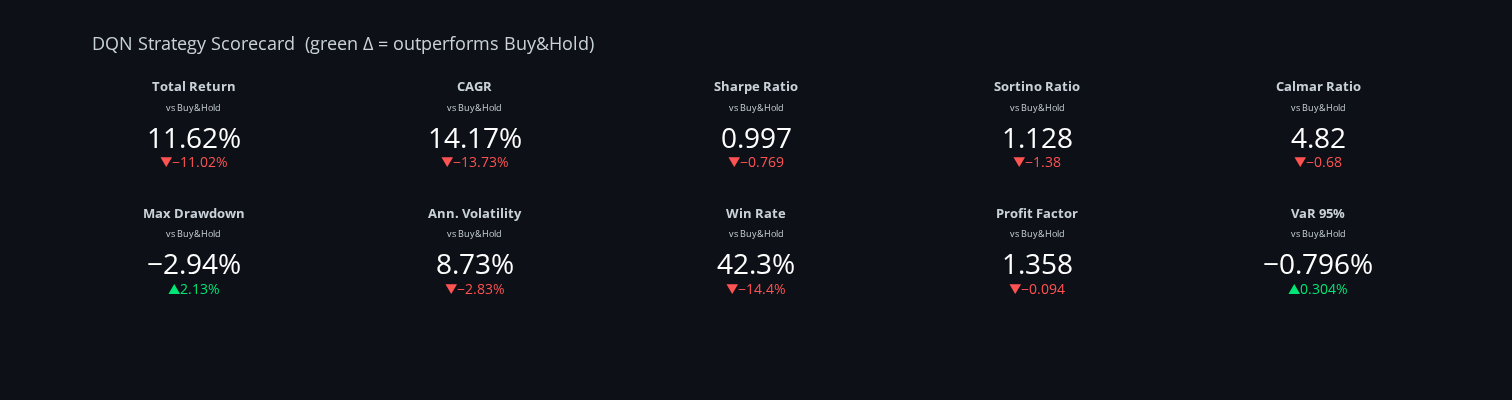

✅ Scorecard rendered.


In [3]:
def color_delta(val, better_positive=True):
    """Return green/red color based on sign."""
    if better_positive:
        return '#00e676' if val >= 0 else '#ff5252'
    else:
        return '#00e676' if val <= 0 else '#ff5252'

METRIC_DEFS = [
    ('Total Return',   'total_return',   '%',  True),
    ('CAGR',           'cagr',           '%',  True),
    ('Sharpe Ratio',   'sharpe',         '',   True),
    ('Sortino Ratio',  'sortino',        '',   True),
    ('Calmar Ratio',   'calmar',         '',   True),
    ('Max Drawdown',   'max_drawdown',   '%',  False),
    ('Ann. Volatility','ann_volatility', '%',  False),
    ('Win Rate',       'win_rate',       '%',  True),
    ('Profit Factor',  'profit_factor',  '',   True),
    ('VaR 95%',        'var_95',         '%',  False),
]

fig_sc = make_subplots(
    rows=2, cols=5,
    specs=[[{'type':'indicator'}]*5, [{'type':'indicator'}]*5]
)

for idx, (label, key, unit, pos_good) in enumerate(METRIC_DEFS):
    row = idx // 5 + 1
    col = idx %  5 + 1
    s_val = strat.get(key, 0)
    b_val = bnh.get(key, 0)
    delta = round(s_val - b_val, 3)

    fig_sc.add_trace(
        go.Indicator(
            mode='number+delta',
            value=s_val,
            number={'suffix': unit, 'font': {'size': 28, 'color': '#ffffff'}},
            delta={'reference': b_val, 'relative': False,
                   'suffix': unit,
                   'increasing': {'color': '#00e676'},
                   'decreasing': {'color': '#ff5252'}},
            title={'text': f'<b>{label}</b><br><sub>vs Buy&Hold</sub>',
                   'font': {'size': 13}},
        ),
        row=row, col=col
    )

fig_sc.update_layout(
    template='plotly_dark',
    height=400,
    title={'text': '🤖 DQN Strategy Scorecard  (green Δ = outperforms Buy&Hold)',
           'font': {'size': 18}},
    paper_bgcolor='#0d1117',
    font={'color': '#c9d1d9'}
)
fig_sc.show()
fig_sc.write_html(str(METRICS / 'scorecard.html'))
print('✅ Scorecard rendered.')

## 3. Full Strategy Dashboard

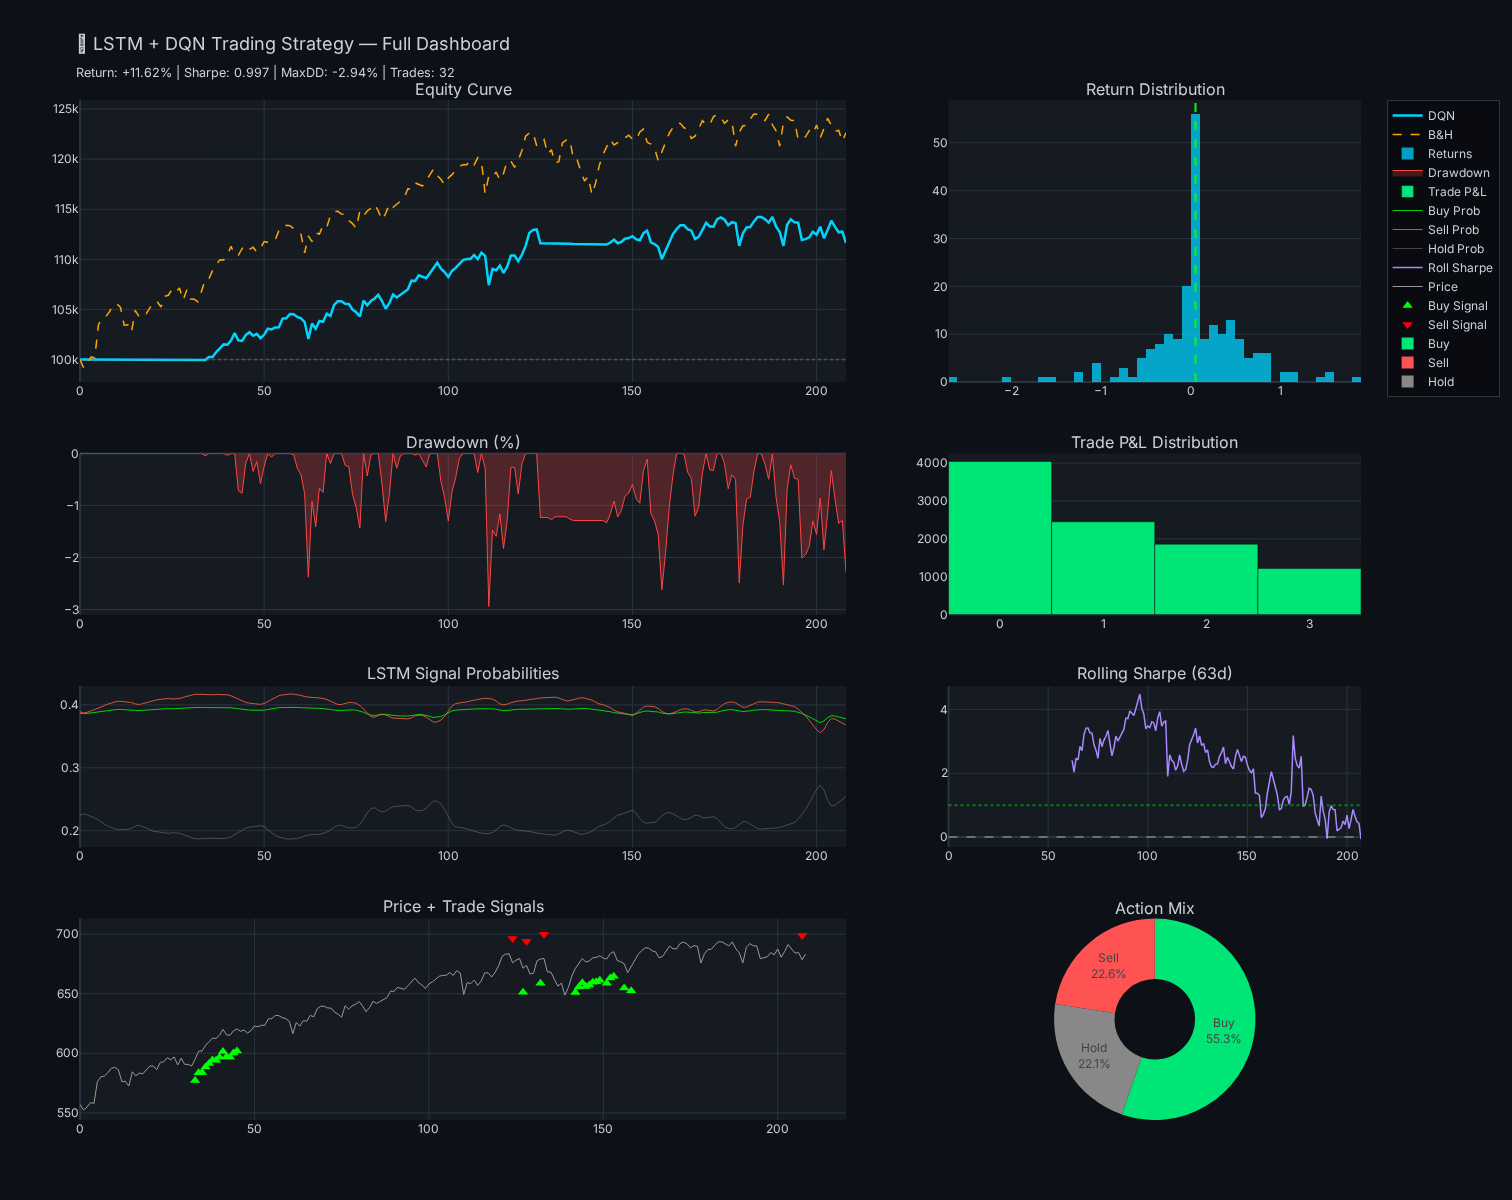

✅ Full dashboard saved → results/metrics/full_dashboard.html


In [4]:
T     = len(port_history)
steps = list(range(T))

peak_strat = np.maximum.accumulate(port_history)
dd_strat   = (port_history - peak_strat) / peak_strat * 100

# LSTM signal probabilities
lp = lstm_data['probs'][:T]   # (T, 3)
hold_p = lp[:, 0]
buy_p  = lp[:, 1]
sell_p = lp[:, 2]

# Daily returns
daily_rets = np.diff(port_history) / port_history[:-1]
roll_sharpe = pd.Series(daily_rets).rolling(63).apply(
    lambda x: x.mean() / (x.std() + 1e-8) * np.sqrt(252), raw=True
)

fig_dash = make_subplots(
    rows=4, cols=2,
    column_widths=[0.65, 0.35],
    row_heights=[0.35, 0.2, 0.2, 0.25],
    specs=[
        [{'rowspan': 1}, {'rowspan': 1}],
        [{'rowspan': 1}, {'rowspan': 1}],
        [{'rowspan': 1}, {'rowspan': 1}],
        [{'rowspan': 1}, {'type':'pie'}],
    ],
    subplot_titles=[
        'Equity Curve', 'Return Distribution',
        'Drawdown (%)', 'Trade P&L Distribution',
        'LSTM Signal Probabilities', 'Rolling Sharpe (63d)',
        'Price + Trade Signals', 'Action Mix',
    ],
    shared_xaxes=False,
    vertical_spacing=0.07,
    horizontal_spacing=0.08
)

# 1. Equity curve
fig_dash.add_trace(go.Scatter(x=steps, y=port_history,
    line=dict(color='#00d4ff', width=2.5), name='DQN'), row=1, col=1)
fig_dash.add_trace(go.Scatter(x=steps, y=bnh_values[:T],
    line=dict(color='#ffa500', width=1.5, dash='dash'), name='B&H'), row=1, col=1)
fig_dash.add_hline(y=initial_cap, line_dash='dot', line_color='gray', opacity=0.4, row=1, col=1)

# 2. Return distribution
fig_dash.add_trace(go.Histogram(x=daily_rets * 100, nbinsx=50,
    marker_color='#00d4ff', opacity=0.75, name='Returns'), row=1, col=2)
fig_dash.add_vline(x=np.mean(daily_rets) * 100, line_dash='dash',
    line_color='lime', row=1, col=2)

# 3. Drawdown
fig_dash.add_trace(go.Scatter(x=steps, y=dd_strat, fill='tozeroy',
    line=dict(color='#ff4444', width=1), fillcolor='rgba(255,68,68,0.25)',
    name='Drawdown'), row=2, col=1)

# 4. Trade P&L
if len(trade_df) > 0:
    colors = ['#00e676' if p > 0 else '#ff5252' for p in trade_df['pnl']]
    fig_dash.add_trace(go.Bar(x=list(range(len(trade_df))), y=trade_df['pnl'],
        marker_color=colors, name='Trade P&L'), row=2, col=2)
else:
    fig_dash.add_annotation(text='No completed trades', row=2, col=2,
        xref='paper', yref='paper', x=0.5, y=0.5, showarrow=False)

# 5. LSTM probs
fig_dash.add_trace(go.Scatter(y=buy_p.tolist(), mode='lines',
    line=dict(color='lime', width=1), name='Buy Prob', opacity=0.8), row=3, col=1)
fig_dash.add_trace(go.Scatter(y=sell_p.tolist(), mode='lines',
    line=dict(color='tomato', width=1), name='Sell Prob', opacity=0.8), row=3, col=1)
fig_dash.add_trace(go.Scatter(y=hold_p.tolist(), mode='lines',
    line=dict(color='gray', width=1), name='Hold Prob', opacity=0.5), row=3, col=1)

# 6. Rolling Sharpe
fig_dash.add_trace(go.Scatter(y=roll_sharpe.tolist(), mode='lines',
    line=dict(color='#aa88ff', width=1.5), name='Roll Sharpe'), row=3, col=2)
fig_dash.add_hline(y=0, line_dash='dash', line_color='white', opacity=0.3, row=3, col=2)
fig_dash.add_hline(y=1, line_dash='dot', line_color='lime', opacity=0.4, row=3, col=2)

# 7. Price + signals
buy_steps   = [s for t,s,p,q in trade_log if t=='BUY'  and s < T]
sell_steps  = [s for t,s,p,q in trade_log if t=='SELL' and s < T]
buy_prices  = [price_series[s] for s in buy_steps if s < len(price_series)]
sell_prices = [price_series[s] for s in sell_steps if s < len(price_series)]

fig_dash.add_trace(go.Scatter(y=price_series.tolist(), mode='lines',
    line=dict(color='#999999', width=1), name='Price'), row=4, col=1)
fig_dash.add_trace(go.Scatter(x=buy_steps, y=[p*0.97 for p in buy_prices], mode='markers',
    marker=dict(symbol='triangle-up', size=9, color='lime'), name='Buy Signal'), row=4, col=1)
fig_dash.add_trace(go.Scatter(x=sell_steps, y=[p*1.03 for p in sell_prices], mode='markers',
    marker=dict(symbol='triangle-down', size=9, color='red'), name='Sell Signal'), row=4, col=1)

# 8. Action pie
action_log = eval_data['action_log']
n_hold = action_log.count(0)
n_buy  = action_log.count(1)
n_sell = action_log.count(2)
fig_dash.add_trace(go.Pie(
    labels=['Hold', 'Buy', 'Sell'],
    values=[n_hold, n_buy, n_sell],
    marker_colors=['#888888', '#00e676', '#ff5252'],
    hole=0.4, textinfo='label+percent',
    name='Action Mix'
), row=4, col=2)

fig_dash.update_layout(
    height=1200,
    template='plotly_dark',
    paper_bgcolor='#0d1117',
    plot_bgcolor='#161b22',
    font={'color': '#c9d1d9', 'family': 'Inter, sans-serif'},
    title={
        'text': ('🧠 LSTM + DQN Trading Strategy — Full Dashboard<br>'
                 f'<sub>Return: {strat["total_return"]:+.2f}% | '
                 f'Sharpe: {strat["sharpe"]:.3f} | '
                 f'MaxDD: {strat["max_drawdown"]:.2f}% | '
                 f'Trades: {len(trade_log)}</sub>'),
        'font': {'size': 18}
    },
    showlegend=True,
    legend=dict(bgcolor='rgba(0,0,0,0.3)', bordercolor='#30363d', borderwidth=1)
)
fig_dash.show()
fig_dash.write_html(str(METRICS / 'full_dashboard.html'))
print('✅ Full dashboard saved → results/metrics/full_dashboard.html')

## 4. Print Final Summary

In [5]:
print('\n' + '=' * 60)
print('  🏆 FINAL STRATEGY SUMMARY')
print('=' * 60)
rows = [
    ('Total Return',    f"{strat['total_return']:+.2f}%",  f"{bnh['total_return']:+.2f}%"),
    ('CAGR',           f"{strat['cagr']:+.2f}%",          f"{bnh['cagr']:+.2f}%"),
    ('Sharpe Ratio',   f"{strat['sharpe']:.3f}",           f"{bnh['sharpe']:.3f}"),
    ('Sortino Ratio',  f"{strat['sortino']:.3f}",          f"{bnh['sortino']:.3f}"),
    ('Max Drawdown',   f"{strat['max_drawdown']:.2f}%",    f"{bnh['max_drawdown']:.2f}%"),
    ('Win Rate',       f"{strat['win_rate']:.1f}%",        f"{bnh['win_rate']:.1f}%"),
    ('Profit Factor',  f"{strat['profit_factor']:.3f}",    f"{bnh['profit_factor']:.3f}"),
    ('Final Value',    f"${strat['final_value']:,.0f}",     f"${bnh['final_value']:,.0f}"),
]
print(f"  {'Metric':<22} {'DQN Strategy':>14} {'Buy & Hold':>14}")
print('-' * 55)
for label, s, b in rows:
    print(f"  {label:<22} {s:>14} {b:>14}")
print('=' * 60)
print('\n  📁 Output files:')
print('     results/metrics/full_dashboard.html')
print('     results/metrics/scorecard.html')
print('     results/metrics/equity_curve.html')
print('     results/metrics/rolling_sharpe.html')
print('     results/metrics/performance_report.json')
print('     results/trades/trade_log.csv')


  🏆 FINAL STRATEGY SUMMARY
  Metric                   DQN Strategy     Buy & Hold
-------------------------------------------------------
  Total Return                  +11.62%        +22.64%
  CAGR                          +14.17%        +27.90%
  Sharpe Ratio                    0.997          1.766
  Sortino Ratio                   1.128          2.508
  Max Drawdown                   -2.94%         -5.07%
  Win Rate                        42.3%          56.7%
  Profit Factor                   1.358          1.452
  Final Value                  $111,621       $122,641

  📁 Output files:
     results/metrics/full_dashboard.html
     results/metrics/scorecard.html
     results/metrics/equity_curve.html
     results/metrics/rolling_sharpe.html
     results/metrics/performance_report.json
     results/trades/trade_log.csv
